*Extra analysis of the subway service ridership scripts*. In particular, applying different factors to get a better estimate of 2025 ridership. 

# Imports/Installation

In [2]:
import gtfs_kit as gk
import pandas as pd 
import numpy as np
import folium
from geodatasets import get_path
import shapely
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import tab20
import matplotlib.cm as cm
import matplotlib.colors as mcolors
mpl.rcParams['figure.dpi'] = 150
sns.set(style='whitegrid')

In [3]:
orig_stations_df = pd.read_csv("../data/MTA_Subway_Stations_20240325.csv")
orig_stations_df = orig_stations_df[orig_stations_df['Borough']!='SI'] 
orig_stations_df = orig_stations_df.drop(columns=['Division', 'ADA', 'ADA Northbound', 'ADA Southbound', 'ADA Notes'
                                                , 'North Direction Label', 'South Direction Label'])

In [4]:
yearly_ridership = pd.read_csv("../saved_data/routes_yearly_ridership.csv", index_col=0)
day_hour_ridership = pd.read_csv("../saved_data/routes_day_hour_ridership.csv", index_col=0)
routes_day_hour_station_ridership = pd.read_csv("../saved_data/routes_day_hour_station_ridership.csv", index_col=0)

## Plotting

In [5]:
color_list = ['#D82233',  '#009952', '#9A38A1', '#EB6800', '#F6BC26', '#F6BC26'
              , '#0062CF', '#0062CF', '#F6BC26', '#D82233', '#7C858C'
              , '#009952',  '#EB6800', '#0062CF','#D82233', '#009952',
              '#EB6800', '#EB6800', '#8E5C33', '#799534'
              , '#7C858C','#7C858C', '#7C858C']

/var/folders/8x/kvnrx4697fv2091hzl57dkbr0000gn/T/ipykernel_41848/3518185237.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(yearly_ridership, x='route_id', y='Adjusted_unlinked_2025'


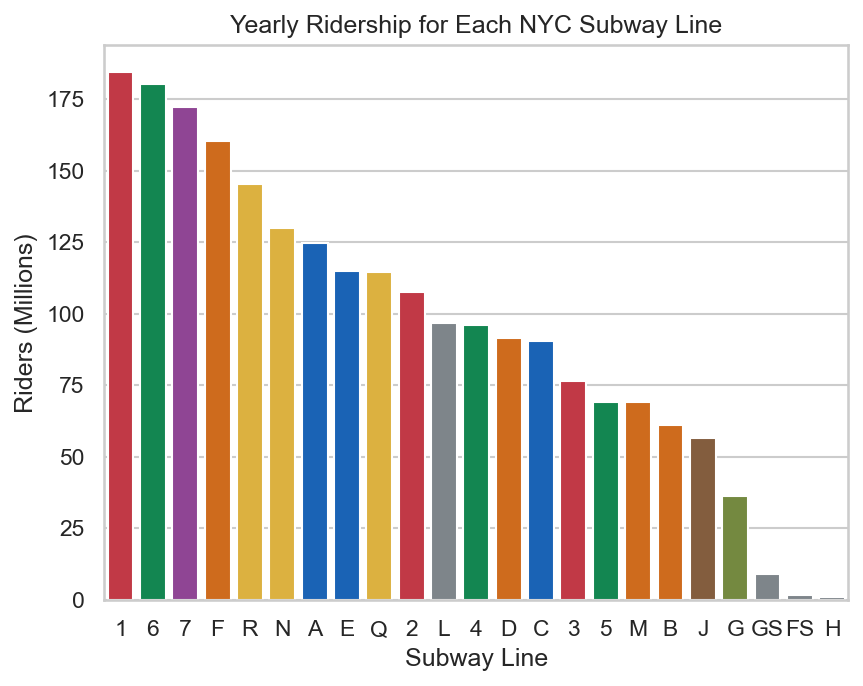

In [6]:
ax = sns.barplot(yearly_ridership, x='route_id', y='Adjusted_unlinked_2025'
            , palette=sns.color_palette(color_list))
ax.set_title("Yearly Ridership for Each NYC Subway Line")
ax.set_ylabel("Riders (Millions)")
ax.set_xlabel("Subway Line")
fig = ax.get_figure()
# fig.savefig("../images/yearly_service_ridership_plot.png")
# fig.savefig("../saved_data/yearly_service_ridership_plot.png")

### Comparing to All Modes of Transportation

In [7]:
# yearly_ridership.columns
yearly_ridership.tail()

,route_id,yearly_ridership_MM,frequency_capacity,daily_ridership_weekday,crowdedness,yearly_ridership_unlinked_MM,Adjusted_unlinked_2025,Adjusted_unlinked_2025_daily_thousands,crowdedness_unlinked
18,J,30.78,108193472.0,93.44,0.28,52.07,56.41,171.24,0.52
19,G,19.75,49748800.0,58.34,0.40,33.40,36.19,106.92,0.73
20,GS,4.84,4059720.0,15.06,1.19,8.19,8.87,27.59,2.18
21,FS,0.85,2778888.0,2.44,0.31,1.44,1.56,4.48,0.56
22,H,0.47,5713920.0,1.32,0.08,0.80,0.87,2.42,0.15


In [8]:
## ENTERING NEW MODES 
#### citi bike: 44 MM per year (2024): https://www.nyc.gov/html/dot/downloads/pdf/bike-share-usage-data-report-q2-2025.pdf
yearly_ridership.iloc[-1] = ['Citi_Bike', 44, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
#### MTA Data on most of the others: https://data.ny.gov/Transportation/MTA-Daily-Ridership-and-Traffic-Beginning-2020/sayj-mze2/explore/query/SELECT%20%60mode%60%2C%20sum%28%60count%60%29%0AWHERE%0A%20%20%60date%60%0A%20%20%20%20BETWEEN%20%222025-01-01T00%3A00%3A00%22%20%3A%3A%20floating_timestamp%0A%20%20%20%20AND%20%222026-01-01T00%3A00%3A00%22%20%3A%3A%20floating_timestamp%0AGROUP%20BY%20%60mode%60/page/aggregate
yearly_ridership.iloc[-1] = ['Access-A-Ride', 13.6, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
yearly_ridership.iloc[-1] = ['Bus', 439.2, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
yearly_ridership.iloc[-1] = ['LIRR', 81.5, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
yearly_ridership.iloc[-1] = ['MNR', 69.5, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
yearly_ridership.iloc[-1] = ['Congestion_Pricing_Zone', 178.5, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
yearly_ridership.iloc[-1] = ['Bridges&Tunnels', 341, np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]

In [9]:
## ENTERING NEW MODES 
#### citi bike: 44 MM per year (2024): https://www.nyc.gov/html/dot/downloads/pdf/bike-share-usage-data-report-q2-2025.pdf
#### MTA Data on most of the others: https://data.ny.gov/Transportation/MTA-Daily-Ridership-and-Traffic-Beginning-2020/sayj-mze2/explore/query/SELECT%20%60mode%60%2C%20sum%28%60count%60%29%0AWHERE%0A%20%20%60date%60%0A%20%20%20%20BETWEEN%20%222025-01-01T00%3A00%3A00%22%20%3A%3A%20floating_timestamp%0A%20%20%20%20AND%20%222026-01-01T00%3A00%3A00%22%20%3A%3A%20floating_timestamp%0AGROUP%20BY%20%60mode%60/page/aggregate
#### PATH: https://en.wikipedia.org/wiki/PATH_(rail_system)#:~:text=In%202025%2C%20the%20system%20saw,system%20in%20the%20United%20States.
#### NYC Ferry: https://edc.nyc/press-release/nyc-ferry-celebrates-50-millionth-rider#:~:text=In%20FY2025%2C%20NYC%20Ferry%20once,commuters%20from%20across%20the%20city.
#### SI Ferryu: https://en.wikipedia.org/wiki/Staten_Island_Ferry#:~:text=With%2016%2C692%2C900%20riders%20in%202025,Island%20and%20the%20other%20boroughs.
#### NJ Transit (all rail): https://en.wikipedia.org/wiki/NJ_Transit_Rail_Operations#:~:text=The%20commuter%20rail%20lines%20saw,North%20America%20by%20route%20length.
#### NJ Transit (bus): https://en.wikipedia.org/wiki/NJ_Transit_Bus_Operations#:~:text=It%20operates%20its%20own%20lines,had%20a%20ridership%20of%20136%2C295%2C400.
#### NYC Total Commute Bike Usage (2023): https://www.nyc.gov/html/dot/html/bicyclists/bikestats.shtml
#### Amtrak in NYC (2025): https://amtrakguide.com/2026/01/31/busiest-amtrak-stations-2025/
#### High-Volume Taxi Trips (2024): https://citymeetings.nyc/meetings/new-york-city-council/2025-03-19-1015-am-committee-on-transportation-and-infrastructure/chapter/tlc-industry-overview-and-trip-statistics/
## other list of transit routes: https://www.traipsingthrutransit.com/nyc-transit-ridership
data_lists = [['Citi_Bike', 44],['Access-A-Ride', 13.6], ['NYC Bus', 439.2], ['LIRR', 81.5],['MNR', 69.5]
              , ['Congestion_Pricing_Zone', 178.5], ['Bridges&Tunnels', 341], ['Subway', 1284.4], ['PATH', 64.3]
              , ['NYC Ferry', 7.4], ['SI Ferry', 16.7], ['NJ Transit Commuter Rail', 62], ['NJ Transit Bus', 136.2]
              , ['NYC Bike Commutes', 226.3], ['Amtrak', 13], ['Taxi', 239]]
all_modes_ridership_df = pd.DataFrame(data = data_lists, columns = ['Mode', 'Yearly_Ridership_2025']).sort_values(by='Yearly_Ridership_2025', ascending=False)

In [10]:
all_modes_ridership_df

,Mode,Yearly_Ridership_2025
7,Subway,1284.4
2,NYC Bus,439.2
6,Bridges&Tunnels,341.0
15,Taxi,239.0
13,NYC Bike Commutes,226.3
5,Congestion_Pricing_Zone,178.5
12,NJ Transit Bus,136.2
3,LIRR,81.5
4,MNR,69.5
8,PATH,64.3


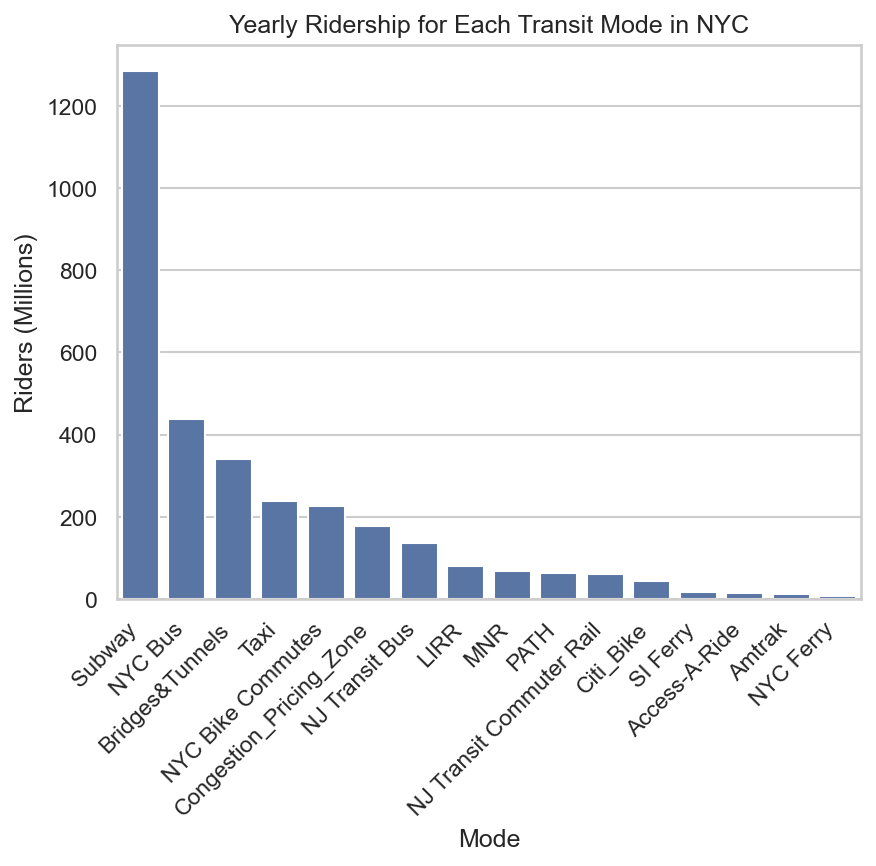

In [11]:
ax = sns.barplot(all_modes_ridership_df, x='Mode', y='Yearly_Ridership_2025')
ax.set_title("Yearly Ridership for Each Transit Mode in NYC")
ax.set_ylabel("Riders (Millions)")
ax.set_xlabel("Mode")
plt.xticks(rotation=45, ha='right')
fig = ax.get_figure()

In [12]:
## GROUPING MODES TOGETHER 
grouped_data_lists = [['Bike', 270.3]
                      , ['Ferry', 24.1]
                      , ['Bus', 575.4]
                      , ['Subway/PATH', 1348.7]
                      , ['Commuter Rail/Amtrak', 226]
                      , ['Taxi/Access-A-Ride', 252.6]
]
all_modes_ridership_grouped_df = pd.DataFrame(data = grouped_data_lists, columns = ['Mode', 'Yearly_Ridership_2025']).sort_values(by='Yearly_Ridership_2025', ascending=False)

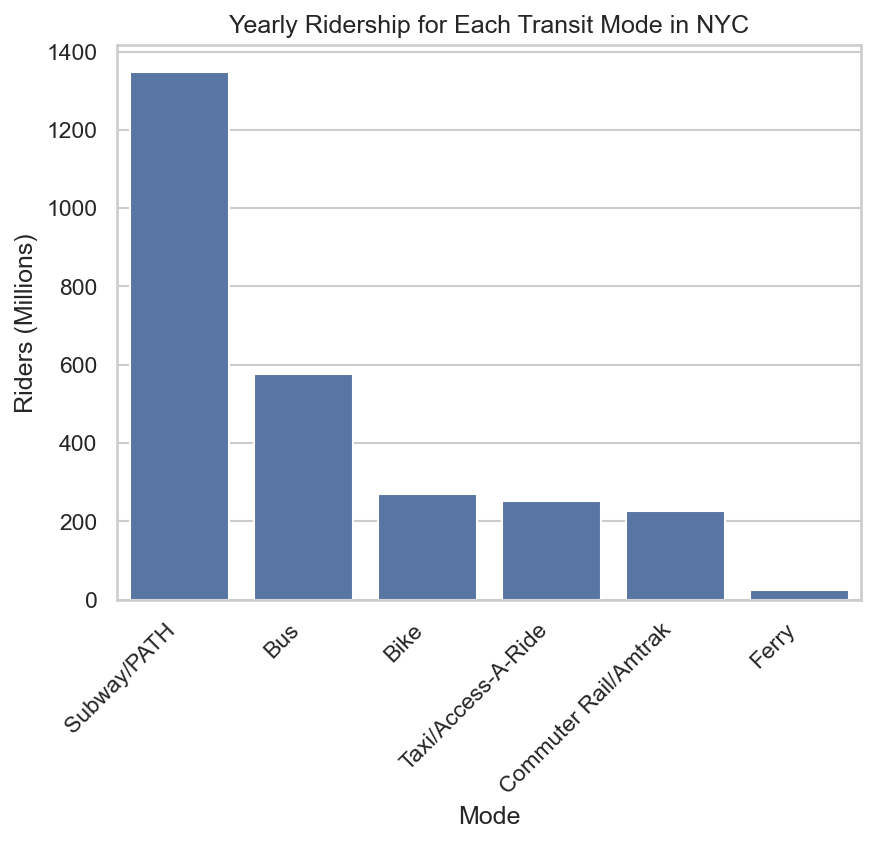

In [13]:
ax = sns.barplot(all_modes_ridership_grouped_df, x='Mode', y='Yearly_Ridership_2025')
ax.set_title("Yearly Ridership for Each Transit Mode in NYC")
ax.set_ylabel("Riders (Millions)")
ax.set_xlabel("Mode")
plt.xticks(rotation=45, ha='right')
fig = ax.get_figure()

## Comparison to anita.garden Data (using wayfinding)
https://anita.garden/nycriders/

In [14]:
10.89 + 145.08 

155.97000000000003

In [15]:
yearly_ridership[['route_id', 'daily_ridership_weekday', 'Adjusted_unlinked_2025_daily_thousands']]
# yearly_ridership.columns
# J = 145.08 + Z = 10.89.... N = 270.19 + W = 152.8
anita_garden_daily_ridership = {'1': 504.09, '2': 356.65, '3': 262.09
                               , '4': 425.24, '5': 326.94, '6': 567.03
                               , '7': 507.53
                               , 'A': 452.4, 'C': 220.51, 'E': 407.69
                               , 'B': 257.34, 'D': 292.76, 'F': 483.88, 'M': 256.11
                               , 'N': 422.99 , 'Q': 340.84, 'R': 375.93
                               , 'G': 148.53
                               , 'J': 155.97
                               , 'L': 359.79
                               , 'GS': 72.21, 'FS': 11.54, 'H': 2.46}
anita_garden_daily_ridership_df = pd.DataFrame.from_dict(anita_garden_daily_ridership, orient='index').reset_index()
anita_garden_daily_ridership_df.columns = ['route_id', 'daily_ridership_wayfinding']

In [16]:
# Combine the anita_garden daily_ridership with the Adjusted_unlinked_2025_daily_thousands
daily_ridership_df = pd.merge(yearly_ridership, anita_garden_daily_ridership_df)

In [17]:
daily_ridership_df[['route_id', 'daily_ridership_weekday', 'Adjusted_unlinked_2025_daily_thousands', 'daily_ridership_wayfinding']]

,route_id,daily_ridership_weekday,Adjusted_unlinked_2025_daily_thousands,daily_ridership_wayfinding
0,1,309.13,566.51,504.09
1,6,311.57,570.98,567.03
2,7,291.40,534.01,507.53
3,F,270.73,496.13,483.88
4,R,236.88,434.09,375.93
5,N,224.21,410.88,422.99
6,A,208.42,381.94,452.40
7,E,198.37,363.52,407.69
8,Q,183.91,337.02,340.84
9,2,178.32,326.77,356.65


In [18]:
daily_ridership_df['percent_difference'] = [round(1 - (daily_ridership_df['Adjusted_unlinked_2025_daily_thousands'][x] /
                                                daily_ridership_df['daily_ridership_wayfinding'][x]), 2)
                                            for x in range(len(daily_ridership_df))    ]

### Examining results

In [19]:
# in general I was 10% off
daily_ridership_df['percent_difference'].mean()
# I overestimated the number of transfers on the: C, R, 1, J, 7, F, 6
# I underestimated the number of transfers on the: GS, FS, 4, 5, G, L, A, E, 3, B, D, 2
daily_ridership_df[['route_id', 'percent_difference']].sort_values(by='percent_difference', ascending=False)

,route_id,percent_difference
20,GS,0.62
21,FS,0.61
11,4,0.30
15,5,0.29
19,G,0.28
10,L,0.22
6,A,0.16
7,E,0.11
14,3,0.10
17,B,0.09


In [69]:
# daily_ridership_df[['route_id', 'daily_ridership_wayfinding']].sort_values(by='daily_ridership_wayfinding', ascending=False)

In [21]:
# to get yearly ridership, I need to get the ratio of the above values per unlinked total trips: 2040132000
## getting 2025 unlinked trip ratio by multiplying 2024 unlinked trip ratio by growth rate 
unlinked_trips_2025 = 2040132000 * (638233041 / 589117753)
unlinked_trips_2025

2210219678.1046796

In [28]:
(638233041 / 589117753)

1.0833709182075864

In [33]:
daily_ridership_df['daily_ridership_wayfinding'].sum()

np.float64(7208.06)

In [67]:
daily_ridership_df['yearly_ridership_wayfinding'] = round(((daily_ridership_df['daily_ridership_wayfinding'] / 7208.06) 
                                                        * unlinked_trips_2025) / 1000000 , 3)
daily_ridership_df = daily_ridership_df.sort_values(by='yearly_ridership_wayfinding', ascending=False)

In [68]:
# make a chart of her predictions versus mine (mine is just a line not a bar)
daily_ridership_df[['route_id', 'Adjusted_unlinked_2025', 'yearly_ridership_wayfinding']].sort_values(by='yearly_ridership_wayfinding', ascending=False)
# daily_ridership_df['yearly_ridersip_wayfinding'].sum()
# daily_ridership_df['Adjusted_unlinked_2025'].sum()

,route_id,Adjusted_unlinked_2025,yearly_ridership_wayfinding
1,6,180.18,173.869
2,7,172.43,155.625
0,1,184.54,154.570
3,F,160.25,148.373
6,A,124.76,138.720
11,4,96.00,130.392
5,N,129.81,129.702
7,E,114.96,125.011
4,R,145.23,115.272
10,L,96.85,110.323


In [64]:
color_list_wayfinding = [ '#009952', '#9A38A1', '#D82233', '#EB6800', '#0062CF', '#009952'
                         , '#F6BC26', '#0062CF', '#F6BC26', '#7C858C'
                        , '#D82233', '#F6BC26', '#009952'
                        ,  '#EB6800','#D82233',
                        '#EB6800', '#EB6800', '#0062CF', '#8E5C33', '#799534'
                        , '#7C858C','#7C858C', '#7C858C']

/var/folders/8x/kvnrx4697fv2091hzl57dkbr0000gn/T/ipykernel_41848/3608832196.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(daily_ridership_df, x='route_id', y='yearly_ridership_wayfinding'
/var/folders/8x/kvnrx4697fv2091hzl57dkbr0000gn/T/ipykernel_41848/3608832196.py:1: UserWarning: The palette list has more values (23) than needed (22), which may not be intended.
  ax = sns.barplot(daily_ridership_df, x='route_id', y='yearly_ridership_wayfinding'


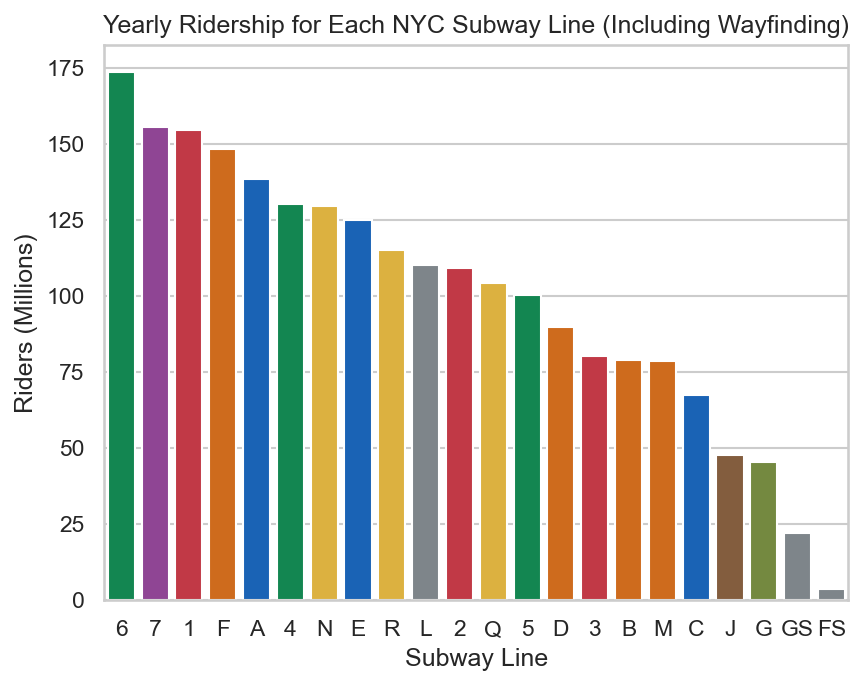

In [66]:
ax = sns.barplot(daily_ridership_df, x='route_id', y='yearly_ridership_wayfinding'
            , palette=sns.color_palette(color_list_wayfinding))
ax.set_title("Yearly Ridership for Each NYC Subway Line (Including Wayfinding)")
ax.set_ylabel("Riders (Millions)")
ax.set_xlabel("Subway Line")
fig = ax.get_figure()
fig.savefig("../images/yearly_service_ridership_wayfinding_plot.png")
# fig.savefig("../saved_data/yearly_service_ridership_plot.png")